# Proyek Capstone: CareerLens

## Pertanyaan Bisnis
1. Bidang karir apa yang memiliki jumlah role terbanyak?
2. Skill apa yang paling sering dibutuhkan lintas role?
3. Bagaimana distribusi skor RIASEC antar role?
4. Bagaimana distribusi platform pembelajaran (learning resources)?

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re

## Data Wrangling

Karena tidak tersedia dataset publik yang sesuai dengan kebutuhan sistem rekomendasi karir ini, data dikumpulkan secara mandiri melalui:
- scraping informasi role/pekerjaan
- pengumpulan estimasi gaji dari berbagai sumber
- kurasi roadmap pembelajaran
- penyusunan learning resources dan dummy project sesuai role

Dataset mentah kemudian melalui proses cleaning dan standarisasi sebelum digunakan untuk analisis.

### Gathering Data

In [ ]:
# datasets
master_roles_df = pd.read_csv('https://drive.google.com/uc?export=download&id=1BWkawcuejBIV_fY4UaKO2bIqovPNe51K')
roles_df = pd.read_csv('https://drive.google.com/uc?export=download&id=17nZETy2j8JoQn7WjDKhs1KjHfGN_u6Wj')
learning_resources_df = pd.read_csv('https://drive.google.com/uc?export=download&id=1TyqSfhtf-EwgArZVzRlVBFZcZkRSkBtO')
dummy_projects_df = pd.read_csv('https://drive.google.com/uc?export=download&id=17PJHV9VB-JABdcuKV3dRoI8b4SbTZXrO')

### Assessing Data

Pada tahap ini dilakukan pemeriksaan kualitas data untuk mengidentifikasi permasalahan seperti missing value, duplicate data, inkonsistensi tipe data, serta potensi outlier sebelum memasuki tahap cleaning data.

In [ ]:
# Menggabungkan seluruh dataset agar pengecekan bisa dilakukan dengan loop
datasets = {
    "master roles": master_roles_df,
    "roles": roles_df,
    "learning resources": learning_resources_df,
    "dummy projects": dummy_projects_df
}

# Melakukan pengecekan setiap dataset
for name, df in datasets.items():

  # Pembatas agar output lebih rapi
  print("\n" + "="*70)
  print(f"\n{name.upper()}")
  print("\n" + "="*70)

  # Menampilkan ukuran dataset (baris, kolom)
  print("\nSHAPE: ", df.shape)
  display(df.head())

  # Menampilkan informasi dataset
  print("\nINFO: ")
  df.info()

  # Mengecek kualitas data
  print("\nCEK KUALITAS DATA")
  print("- Missing Values: ", df.isnull().sum().sum())
  print("- Duplicated Rows: ", df.duplicated().sum())

  # Menampilkan contoh unique values untuk mendeteksi inkonsistensi penulisan data
  print("\nUnique values (sample):")
  for col in df.select_dtypes(include='object').columns:
      print(f"- {col}:", df[col].unique()[:5])



MASTER ROLES


SHAPE:  (68, 6)


,role_id,bidang,nama_role,deskripsi,skill,gaji
0,R001,F01,Software Engineer / Developer,Software Engineer adalah profesional yang mera...,"SQL, Java, Python, Git, JavaScript, HTML, CSS,...",Rp 9.116.248
1,R002,F01,Frontend Developer,Frontend Developer bertanggung jawab membangun...,"CSS, JavaScript, React, Git, HTML, Vue.js, Ang...",Rp 8.981.860
2,R003,F01,Backend Developer,Backend Developer membangun dan mengelola logi...,"RESTful API, PostgreSQL, MongoDB, Express.js, ...",Rp 10.075.485
3,R004,F01,Full Stack Developer,Full Stack Developer memiliki kemampuan untuk ...,"React, HTML, JavaScript, Node.js, Git, SQL, Vu...",Rp 7.298.431
4,R005,F01,Mobile App (Android/iOS) Developer,Mobile App Developer merancang dan membangun a...,"Java, Kotlin, Android Studio, Swift, Git, REST...",Rp 7.003.387



INFO: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   role_id    68 non-null     object
 1   bidang     68 non-null     object
 2   nama_role  68 non-null     object
 3   deskripsi  68 non-null     object
 4   skill      68 non-null     object
 5   gaji       68 non-null     object
dtypes: object(6)
memory usage: 3.3+ KB

CEK KUALITAS DATA
- Missing Values:  0
- Duplicated Rows:  0

Unique values (sample):
- role_id: ['R001' 'R002' 'R003' 'R004' 'R005']
- bidang: ['F01' 'F02' 'F03' 'F04']
- nama_role: ['Software Engineer / Developer' 'Frontend Developer' 'Backend Developer'
 'Full Stack Developer' 'Mobile App (Android/iOS) Developer']
- deskripsi: ['Software Engineer adalah profesional yang merancang, mengembangkan, dan memelihara perangkat lunak berkualitas tinggi untuk memenuhi kebutuhan bisnis. Setiap harinya, mereka menulis dan meninjau kode, be

,role_id,field_id,role_name,R,I,A,S,E,C
0,R001,F01,Software Engineer / Developer,0.435,0.842,0.228,0.135,0.145,0.770
1,R002,F01,Frontend Developer,0.167,0.750,0.750,0.250,0.167,0.583
2,R003,F01,Backend Developer,0.250,0.967,0.167,0.083,0.133,0.833
3,R004,F01,Full Stack Developer,0.250,0.917,0.500,0.167,0.167,0.750
4,R005,F01,Mobile App (Android/iOS) Developer,0.250,0.867,0.417,0.167,0.167,0.700



INFO: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   role_id    68 non-null     object 
 1   field_id   68 non-null     object 
 2   role_name  68 non-null     object 
 3   R          68 non-null     float64
 4   I          68 non-null     float64
 5   A          68 non-null     float64
 6   S          68 non-null     float64
 7   E          68 non-null     float64
 8   C          68 non-null     float64
dtypes: float64(6), object(3)
memory usage: 4.9+ KB

CEK KUALITAS DATA
- Missing Values:  0
- Duplicated Rows:  0

Unique values (sample):
- role_id: ['R001' 'R002' 'R003' 'R004' 'R005']
- field_id: ['F01' 'F02' 'F03' 'F04']
- role_name: ['Software Engineer / Developer' 'Frontend Developer' 'Backend Developer'
 'Full Stack Developer' 'Mobile App (Android/iOS) Developer']


LEARNING RESOURCES


SHAPE:  (978, 7)


,resource_id,role_id,step_number,nama_skill,link_course,tipe,platform
0,RES0001,R001,1,Agile,https://www.coursera.org/learn/agile-project-m...,Video Course + Certificate,Coursera
1,RES0002,R001,1,"Python, Html, Css",https://www.coursera.org/learn/ai-code-generat...,Video Course + Certificate,Coursera
2,RES0003,R001,1,Sql,https://www.coursera.org/learn/analyze-data,Video Course + Certificate,Coursera
3,RES0004,R001,2,Html,https://www.udemy.com/html-online-course/,Video Course + Certificate,Udemy
4,RES0005,R001,2,"Html, Css",https://www.udemy.com/html-tutorial/,Video Course + Certificate,Udemy



INFO: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 978 entries, 0 to 977
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   resource_id  978 non-null    object
 1   role_id      978 non-null    object
 2   step_number  978 non-null    int64 
 3   nama_skill   978 non-null    object
 4   link_course  978 non-null    object
 5   tipe         978 non-null    object
 6   platform     978 non-null    object
dtypes: int64(1), object(6)
memory usage: 53.6+ KB

CEK KUALITAS DATA
- Missing Values:  0
- Duplicated Rows:  0

Unique values (sample):
- resource_id: ['RES0001' 'RES0002' 'RES0003' 'RES0004' 'RES0005']
- role_id: ['R001' 'R002' 'R003' 'R004' 'R005']
- nama_skill: ['Agile' 'Python, Html, Css' 'Sql' 'Html' 'Html, Css']
- link_course: ['https://www.coursera.org/learn/agile-project-management'
 'https://www.coursera.org/learn/ai-code-generation-everyone'
 'https://www.coursera.org/learn/analyze-data'
 'https://www.

,project_id,judul_project,brief_case,instructions,tools_used
0,P001,Enterprise Resource Planning System,Perusahaan membutuhkan sistem terintegrasi unt...,Identifikasi modul utama (inventory finance HR...,Java; Spring Boot; MySQL
1,P002,Responsive Company Website,Perusahaan ingin meningkatkan kehadiran online...,Analisis kebutuhan halaman; Buat wireframe; Im...,React; Tailwind CSS
2,P003,RESTful API Service,Perusahaan membutuhkan backend untuk integrasi...,Definisikan endpoint API; Desain database; Imp...,Node.js; Express; PostgreSQL
3,P004,Full Stack Job Portal,Pengguna membutuhkan platform untuk mencari da...,Rancang fitur utama; Desain database; Bangun f...,MERN Stack
4,P005,Mobile Fitness Tracker App,User ingin memonitor aktivitas kesehatan haria...,Desain UI/UX; Implementasi fitur tracking; Int...,Flutter; Firebase



INFO: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   project_id     68 non-null     object
 1   judul_project  68 non-null     object
 2   brief_case     68 non-null     object
 3   instructions   68 non-null     object
 4   tools_used     68 non-null     object
dtypes: object(5)
memory usage: 2.8+ KB

CEK KUALITAS DATA
- Missing Values:  0
- Duplicated Rows:  0

Unique values (sample):
- project_id: ['P001' 'P002' 'P003' 'P004' 'P005']
- judul_project: ['Enterprise Resource Planning System' 'Responsive Company Website'
 'RESTful API Service' 'Full Stack Job Portal'
 'Mobile Fitness Tracker App']
- brief_case: ['Perusahaan membutuhkan sistem terintegrasi untuk mengelola operasi bisnis secara efisien'
 'Perusahaan ingin meningkatkan kehadiran online dengan website responsif'
 'Perusahaan membutuhkan backend untuk integrasi berbagai layanan i

**Interpretasi**
1. Master Roles
  - `master_roles_df` memiliki 68 baris dengan 6 kolom, yaitu role_id, bidang, nama_role, deskripsi, skill, dan gaji.
  - Kolom skill bertipe object yang berisi banyak skill dalam satu baris, sehingga perlu dilakukan pemisahan menjadi list agar bisa dianalisis lebih lanjut.
  - Kolom gaji juga masih bertipe object, sehingga masih dalam format string (menggunakan Rp). Hal ini perlu diperhatikan karena akan mempengaruhi proses analisis numerik seperti distribusi gaji.
  - Tidak ada missing values dan duplikasi data.

2. Roles (RIASEC)
  - `roles_df` memiliki 68 baris dengan 9 kolom yang berisi nama role dan informasi skor RIASEC (Realistic, Investigative, Artistic, Social, Enterprising, Conventional) untuk setiap role.
  - Seluruh kolom numerik pada RIASEC bertipe float, sehingga siap digunakan untuk analisis lebih lanjut.
  - Tidak ada missing values dan duplikasi data.

3. Learning Resources
  - `learning_resources_df` memiliki jumlah data yang cukup besar, yaitu 978 baris dengan 7 kolom. Dataset ini merepresentasikan roadmap pembelajaran untuk setiap role dalam bentuk step-by-step.
  - Kolom step_number sudah bertipe integer, yang menunjukkan urutan pembelajaran. Kolom lainnya seperti nama_skill, link_course, tipe, dan platform berupa teks.
  - Tidak ada missing values dan duplikasi data. Banyaknya jumlah data ini menunjukkan bahwa setiap role memiliki beberapa tahapan pembelajaran.

4. Dummy Projects
  - `dummy_projects_df` terdiri dari 68 baris dengan 5 kolom, yang berisi contoh project untuk masing-masing role.
  - Seluruh kolom berupa teks, seperti judul_project, brief_case, instructions, dan tools_used. Dataset ini nantinya dapat digunakan untuk melengkapi rekomendasi roadmap dengan contoh project sebagai portofolio.
  - Tidak ada missing values dan duplikasi data.

### Cleaning Data

Pada tahap ini dilakukan pembersihan data pada kolom yang akan digunakan dalam analisis, khususnya kolom *gaji* dan *skill*. Pembersihan dilakukan untuk memastikan data memiliki format yang konsisten dan dapat digunakan dalam perhitungan statistik serta eksplorasi lebih lanjut.

#### Memecah data kolom skill pada `master_roles_df`

In [ ]:
# Memecah skill menjadi list
master_roles_df['skill'] = master_roles_df['skill'].apply(
    lambda x: x if isinstance(x, list) else x.split(',')
)

# Menghapus spasi berlebih
master_roles_df['skill'] = master_roles_df['skill'].apply(
    lambda x: [s.strip() for s in x]
)

In [ ]:
# Memecah setiap skill menjadi baris terpisah
skills_exploded = master_roles_df.explode('skill')

# Menghitung frekuensi skill
skill_counts = skills_exploded['skill'].value_counts().head(15)
skill_counts

,count
skill,
Python,32
SQL,20
Figma,8
Java,8
Excel,8
Google Analytics,7
Tableau,7
AWS,7
Power BI,6


**Interpretasi**

Kolom skill awalnya masih berbentuk string yang berisi beberapa skill dalam satu sel. Oleh karena itu, dilakukan pemisahan menjadi list dan pembersihan spasi agar konsisten. Selanjutnya, data di-*explode* sehingga setiap skill dapat dianalisis secara individual. Hasil awal menunjukkan bahwa beberapa skill muncul lebih sering dibanding skill yang lain.

#### Mengubah data kolom gaji ke dalam format integer

In [ ]:
def konversi_gaji(teks):
    # Cek apakah datanya kosong
    if pd.isna(teks):
        return np.nan

    # Ubah menjadi string
    teks = str(teks)

    # Mencari semua yang bukan angka dan menghapusnya
    angka_str = re.sub(r'\D', '', teks)

    # Mengubah angka menjadi integer
    if angka_str:
        return int(angka_str)
    else:
        return np.nan

# Menerapkan Fungsi ke Kolom gaji
master_roles_df['gaji'] = master_roles_df['gaji'].apply(konversi_gaji)

In [ ]:
print(master_roles_df.head())

  role_id bidang                           nama_role  \
0    R001    F01       Software Engineer / Developer   
1    R002    F01                  Frontend Developer   
2    R003    F01                   Backend Developer   
3    R004    F01                Full Stack Developer   
4    R005    F01  Mobile App (Android/iOS) Developer   

                                           deskripsi  \
0  Software Engineer adalah profesional yang mera...   
1  Frontend Developer bertanggung jawab membangun...   
2  Backend Developer membangun dan mengelola logi...   
3  Full Stack Developer memiliki kemampuan untuk ...   
4  Mobile App Developer merancang dan membangun a...   

                                               skill      gaji  
0  [SQL, Java, Python, Git, JavaScript, HTML, CSS...   9116248  
1  [CSS, JavaScript, React, Git, HTML, Vue.js, An...   8981860  
2  [RESTful API, PostgreSQL, MongoDB, Express.js,...  10075485  
3  [React, HTML, JavaScript, Node.js, Git, SQL, V...   7298431  
4

**Interpretasi**

Kolom gaji awalnya masih dalam format teks dengan berbagai karakter non-numerik. Oleh karena itu, dilakukan pembersihan dengan menghapus seluruh karakter selain angka dan mengonversinya menjadi tipe integer. Setelah proses ini, data gaji menjadi lebih konsisten dan dapat digunakan dalam analisis statistik.

## Explanatory Data Analysis

Pada tahap ini dilakukan eksplorasi untuk memahami distribusi data secara umum menggunakan rangkuman statistik dan deteksi outlier untuk melihat apakah ada nilai yang menyimpang dari pola data yang ada.

### Analisis Gaji

In [ ]:
# Menampilkan statistik deskriptif pada kolom gaji
print("DISTRIBUSI GAJI")
# Mengatur format angka agar lebih mudah dibaca tanpa angka desimal dan menggunakan pemisah ribuan
pd.options.display.float_format = '{:,.0f}'.format
master_roles_df['gaji'].describe()

DISTRIBUSI GAJI


,gaji
count,68
mean,"8,098,626"
std,"3,824,105"
min,"3,000,000"
25%,"5,111,778"
50%,"7,574,323"
75%,"9,796,166"
max,"27,264,928"


**Interpretasi**

Dataset memiliki 68 data dengan rata-rata gaji berada di kisaran 8 juta rupiah. Nilai median berada di sekitar 7,5 juta rupiah, yang menunjukkan bahwa sebagian besar role memiliki gaji di bawah rata-rata.

Rentang gaji pada dataset juga cukup besar, dimulai dari sekitar 3 juta hingga lebih dari 27 juta rupiah. Perbedaan yang cukup jauh antara nilai minimum dan maksimum menunjukkan adanya variasi tingkat gaji antar role.

Nilai kuartil menunjukkan bahwa 50% data gaji berada pada rentang sekitar 5 juta hingga 9,7 juta rupiah. Nilai maksimum yang jauh lebih tinggi dibandingkan kuartil atas juga mengindikasikan adanya beberapa role dengan gaji yang jauh lebih tinggi dibandingkan role lainnya.

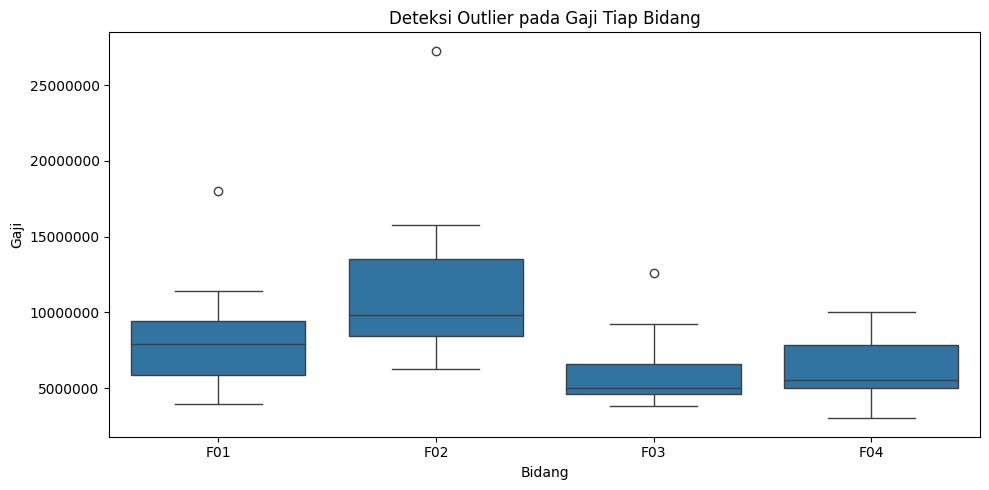

In [ ]:
# Membuat boxplot untuk melihat distribusi gaji serta mendeteksi adanya outlier pada tiap bidang
plt.figure(figsize=(10,5))
plt.ticklabel_format(style='plain', axis='y')
sns.boxplot(data=master_roles_df, x='bidang', y='gaji')
plt.title('Deteksi Outlier pada Gaji Tiap Bidang')
plt.xlabel('Bidang')
plt.ylabel('Gaji')
plt.tight_layout()
plt.show()

**Interpretasi**

Pada visualisasi boxplot, terlihat bahwa distribusi gaji pada setiap bidang memiliki pola yang berbeda. Bidang F02 memiliki rentang gaji yang relatif lebih tinggi dibandingkan bidang lainnya. Selain itu, terdapat beberapa titik yang berada di luar rentang utama data pada beberapa bidang, yang mengindikasikan adanya outlier.

Outlier tersebut kemungkinan merepresentasikan role dengan tingkat senioritas, spesialisasi, atau kebutuhan skill tertentu yang memiliki nilai gaji lebih tinggi dibandingkan mayoritas role lainnya.

### Analisis Skill

In [ ]:
# Menghitung jumlah kemunculan setiap skill
skill_counts = skills_exploded['skill'].value_counts().head(15)
skill_counts

,count
skill,
Python,32
SQL,20
Figma,8
Java,8
Excel,8
Google Analytics,7
Tableau,7
AWS,7
Power BI,6


**Interpretasi**

Berdasarkan hasil analisis, Python merupakan skill yang paling sering muncul dengan total 32 kemunculan. Selain itu, skill seperti SQL, Figma, Java, dan Excel juga memiliki frekuensi yang cukup tinggi dibandingkan skill lainnya.

Hal ini menunjukkan bahwa beberapa skill bersifat lebih umum dan banyak dibutuhkan di berbagai role. Skill seperti Python dan SQL terlihat cukup dominan, yang mengindikasikan bahwa kemampuan pemrograman dan pengolahan data menjadi kebutuhan penting dalam banyak bidang pekerjaan pada dataset ini.

Sementara itu, skill seperti Figma, Tableau, dan Google Analytics menunjukkan bahwa dataset tidak hanya berfokus pada bidang pengembangan perangkat lunak, tetapi juga mencakup role di bidang desain, data, dan analisis bisnis.

### Analisis Skor RIASEC

In [ ]:
# Mengatur format tampilan angka menjadi 3 digit desimal
pd.options.display.float_format = '{:.3f}'.format

# Menampilkan statistik deskriptif untuk setiap dimensi RIASEC
roles_df[['R','I','A','S','E','C']].describe()

,R,I,A,S,E,C
count,68.000,68.000,68.000,68.000,68.000,68.000
mean,0.254,0.777,0.401,0.255,0.341,0.725
std,0.125,0.167,0.304,0.196,0.220,0.180
min,0.013,0.280,0.033,0.083,0.083,0.223
25%,0.167,0.667,0.167,0.083,0.167,0.579
50%,0.250,0.833,0.301,0.167,0.250,0.750
75%,0.333,0.917,0.688,0.354,0.500,0.835
max,0.583,1.000,1.000,0.917,0.917,1.000


In [ ]:
# Menentukan tipe RIASEC dominan pada setiap role dengan mengambil skor tertinggi pada tiap baris
roles_df[['R','I','A','S','E','C']].idxmax(axis=1).value_counts()

,count
I,38
C,13
A,11
E,5
S,1


**Interpretasi**

Dimensi Investigative (I) memiliki rata-rata skor paling tinggi dibandingkan dimensi lainnya. Hal ini menunjukkan bahwa sebagian besar role dalam dataset cenderung membutuhkan kemampuan analitis, pemecahan masalah, dan pola berpikir logis.

Selain itu, dimensi Conventional (C) dan Artistic (A) juga memiliki nilai yang cukup tinggi pada beberapa role. Sementara itu, dimensi Realistic (R) memiliki nilai yang relatif lebih rendah dibandingkan dimensi lainnya.

Hasil analisis dimensi dominan menunjukkan bahwa sebagian besar role didominasi oleh tipe Investigative (I) dengan total 38 role. Hal ini memperlihatkan bahwa dataset lebih banyak berfokus pada bidang yang berkaitan dengan teknologi, analisis, dan pengolahan data.

Selain Investigative, beberapa role juga didominasi oleh dimensi Conventional (C) dan Artistic (A). Sementara itu, tidak terdapat role yang memiliki dimensi Realistic (R) sebagai karakteristik dominan.

### Analisis Learning Resources

In [ ]:
# Mengambil jumlah langkah terakhir pada tiap role untuk mengetahui total step roadmap pembelajaran
steps_per_role = learning_resources_df.groupby('role_id')['step_number'].max()

# Menampilkan statistik deskriptif dari jumlah step roadmap setiap role
steps_per_role.describe()

,step_number
count,68.000
mean,4.985
std,0.121
min,4.000
25%,5.000
50%,5.000
75%,5.000
max,5.000


In [ ]:
# Menghitung jumlah role berdasarkan total step roadmap yang dimiliki
learning_resources_df.groupby('role_id')['step_number'].max().value_counts()

,count
step_number,
5,67
4,1


**Interpretasi**

Sebagian besar role memiliki total 5 tahapan pembelajaran dalam roadmap yang disediakan. Dari 68 role yang ada, sebanyak 67 role memiliki 5 step pembelajaran, sedangkan hanya 1 role yang memiliki 4 step.

Nilai rata-rata jumlah step juga berada di sekitar 5 dengan standar deviasi yang sangat kecil (0.121) yang menunjukkan bahwa struktur roadmap pembelajaran pada dataset dibuat cukup konsisten untuk setiap role.

In [ ]:
# Menghitung jumlah penggunaan setiap platform pembelajaran
learning_resources_df['platform'].value_counts()

,count
platform,
Coursera,886
Udemy,70
Dicoding,15
edX,7


In [ ]:
# Menghitung jumlah tiap tipe resource pembelajaran
learning_resources_df['tipe'].value_counts()

,count
tipe,
Video Course + Certificate,963
Interactive Course + Certificate,15


**Interpretasi**

Sebagian besar resource pembelajaran berasal dari platform Coursera dengan jumlah 886 resource. Platform lain seperti Udemy, Dicoding, dan edX juga digunakan, namun dalam jumlah yang lebih sedikit.

Selain itu, mayoritas resource yang digunakan berupa Video Course + Certificate. Hal ini menunjukkan bahwa roadmap pembelajaran pada dataset lebih banyak berfokus pada pembelajaran berbasis video dan sertifikasi.

### Analisis Skill Overlap

In [ ]:
from itertools import combinations # perlu ga ya?

role_skills = master_roles_df[['nama_role', 'skill']].copy()
role_skills['skill'] = role_skills['skill'].apply(lambda x: set(x))

overlap_results = []

for (role1, skills1), (role2, skills2) in combinations(role_skills.values, 2):
    overlap = len(skills1 & skills2)
    overlap_results.append((role1, role2, overlap))

overlap_df = pd.DataFrame(overlap_results, columns=['role1','role2','overlap'])
overlap_df.sort_values(by='overlap', ascending=False).head(10)

,role1,role2,overlap
885,AR/VR Developer,AR/VR Developer (Unity),9
1979,UI Designer,Product Designer,8
1620,Data Engineer,Data Architect,8
2240,Marketing Analyst,Campaign Analyst,7
2002,UX Designer,Product Designer,7
68,Frontend Developer,Full Stack Developer,7
1613,Data Engineer,Big Data Engineer,6
2,Software Engineer / Developer,Full Stack Developer,6
1673,Product Analyst,Marketing Analyst,6
1689,Big Data Engineer,Data Architect,6


**Interpretasi**

## Visualization & Explanatory Analysis

Pada tahap ini dilakukan visualisasi dan analisis data untuk menjawab pertanyaan bisnis yang telah ditentukan. Visualisasi digunakan untuk membantu memahami pola data secara lebih jelas, seperti bidang karir yang paling banyak tersedia, skill yang paling sering dibutuhkan, distribusi karakteristik RIASEC, serta struktur roadmap pembelajaran pada setiap role.

### Pertanyaan 1:

Bidang karir apa yang memiliki jumlah role terbanyak?

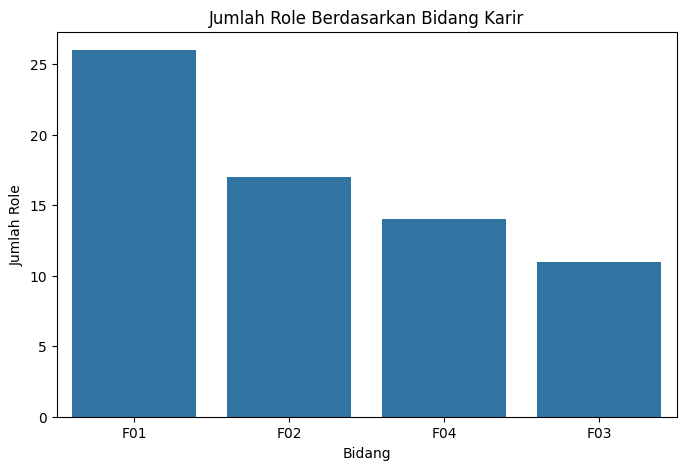

In [ ]:
plt.figure(figsize=(8,5))

bidang_counts = master_roles_df['bidang'].value_counts()

sns.barplot(x=bidang_counts.index, y=bidang_counts.values)

plt.title('Jumlah Role Berdasarkan Bidang Karir')
plt.xlabel('Bidang')
plt.ylabel('Jumlah Role')
plt.show()

**Explanatory Analysis:**

Berdasarkan visualisasi, bidang F01 memiliki jumlah role paling banyak dibandingkan bidang lainnya, yaitu sekitar 26 role. Hal ini menunjukkan bahwa dataset lebih banyak berfokus pada role yang berada pada bidang tersebut.

Sementara itu, bidang F02 dan F04 juga memiliki jumlah role yang cukup banyak, sedangkan bidang F03 memiliki jumlah role paling sedikit pada dataset. Perbedaan jumlah role ini menunjukkan bahwa distribusi bidang karir pada dataset belum sepenuhnya merata.

Banyaknya role pada bidang tertentu kemungkinan menunjukkan tingginya variasi kebutuhan skill dan peluang karir pada bidang tersebut dibandingkan bidang lainnya.

### Pertanyaan 2:

Skill apa yang paling sering dibutuhkan lintas role?

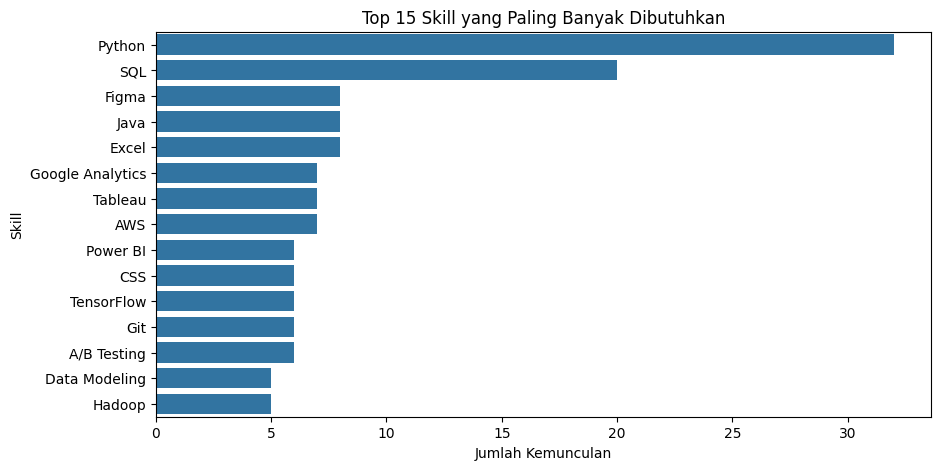

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=skill_counts.values, y=skill_counts.index)

plt.title('Top 15 Skill yang Paling Banyak Dibutuhkan')
plt.xlabel('Jumlah Kemunculan')
plt.ylabel('Skill')

plt.show()

**Explanatory Analysis:**

Berdasarkan visualisasi, Python menjadi skill yang paling banyak dibutuhkan dengan jumlah kemunculan paling tinggi dibandingkan skill lainnya. Selain itu, SQL juga memiliki frekuensi yang cukup besar, yang menunjukkan bahwa kemampuan pemrograman dan pengolahan data menjadi kebutuhan penting pada banyak role dalam dataset.

Beberapa skill lain seperti Figma, Java, Excel, Tableau, dan Google Analytics juga cukup sering muncul. Hal ini menunjukkan bahwa dataset tidak hanya berfokus pada bidang pengembangan perangkat lunak, tetapi juga mencakup bidang desain, data, dan analisis bisnis.

Selain itu, munculnya skill seperti AWS, TensorFlow, dan Hadoop menunjukkan bahwa beberapa role juga membutuhkan kemampuan pada bidang cloud computing, machine learning, dan big data. Secara umum, visualisasi ini menunjukkan bahwa kebutuhan skill pada dataset cukup beragam dan mencerminkan berbagai jenis role di bidang teknologi dan digital.

### Pertanyaan 3:

Bagaimana distribusi skor RIASEC antar role?

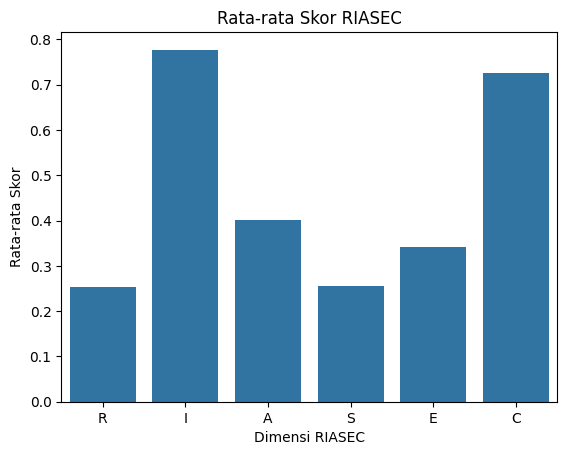

In [ ]:
riasec_mean = roles_df[['R','I','A','S','E','C']].mean()

sns.barplot(x=riasec_mean.index, y=riasec_mean.values)

plt.title('Rata-rata Skor RIASEC')
plt.xlabel('Dimensi RIASEC')
plt.ylabel('Rata-rata Skor')

plt.show()

**Explanatory Analysis:**

Berdasarkan visualisasi, dimensi Investigative (I) memiliki rata-rata skor paling tinggi dibandingkan dimensi RIASEC lainnya. Hal ini menunjukkan bahwa sebagian besar role dalam dataset cenderung membutuhkan kemampuan analitis, pemecahan masalah, serta pola berpikir logis.

Selain itu, dimensi Conventional (C) juga memiliki rata-rata skor yang cukup tinggi. Hal ini mengindikasikan bahwa beberapa role membutuhkan kemampuan yang terstruktur, sistematis, dan detail dalam menyelesaikan pekerjaan.

Sementara itu, dimensi Artistic (A) dan Enterprising (E) memiliki nilai sedang, yang menunjukkan bahwa kreativitas dan kemampuan komunikasi juga tetap dibutuhkan pada beberapa role tertentu.

Dimensi Realistic (R) dan Social (S) memiliki rata-rata skor paling rendah dibandingkan dimensi lainnya. Hal ini menunjukkan bahwa dataset lebih banyak berfokus pada role di bidang teknologi dan analisis dibandingkan pekerjaan yang berhubungan langsung dengan aktivitas fisik atau interaksi sosial yang tinggi.

### Pertanyaan 4:

Bagaimana distribusi platform pembelajaran (learning resources)?

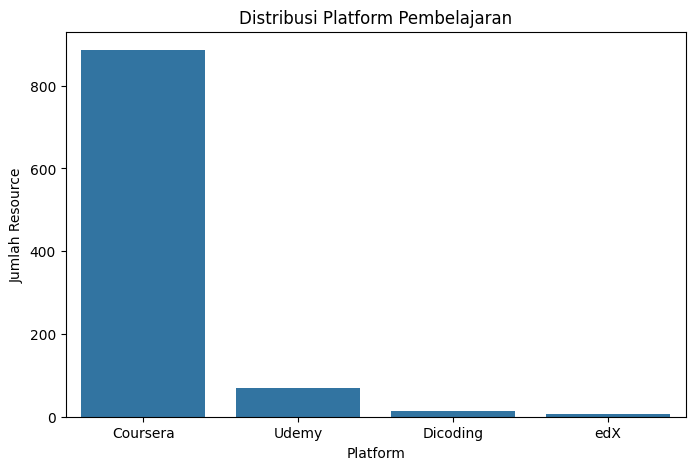

In [ ]:
plt.figure(figsize=(8,5))

platform_counts = learning_resources_df['platform'].value_counts()

sns.barplot(
    x=platform_counts.index,
    y=platform_counts.values
)

plt.title('Distribusi Platform Pembelajaran')
plt.xlabel('Platform')
plt.ylabel('Jumlah Resource')

plt.show()

**Explanatory Analysis:**

Berdasarkan visualisasi, sebagian besar resource pembelajaran pada dataset berasal dari platform Coursera dengan jumlah yang jauh lebih banyak dibandingkan platform lainnya. Sementara itu, platform seperti Udemy, Dicoding, dan edX digunakan dalam jumlah yang relatif lebih sedikit.

Dominasi Coursera menunjukkan bahwa roadmap pembelajaran pada dataset lebih banyak menggunakan resource berbasis kursus online yang terstruktur dan bersertifikat. Selain itu, penggunaan beberapa platform yang berbeda menunjukkan bahwa resource pembelajaran pada sistem tidak hanya bergantung pada satu sumber saja.

Perbedaan jumlah resource antar platform juga menunjukkan bahwa ketersediaan course yang sesuai dengan kebutuhan skill pada setiap role tidak merata di semua platform pembelajaran.

## Feature Engineering

Step:

1. Memastikan skill sudah 'lowercase'
2. Menggabungkan kolom RIASEC pada tabel 'roles_df' dengan kolom skill dan deskripsi pada tabel 'master_roles_df'.
3. Melakukan multi hot encoding menggunakan vektor biner pada kolom 'skill' di tabel 'master_roles_df'

### Menggabungkan kolom RIASEC pada tabel 'roles_df' dengan kolom skill dan deskripsi pada tabel 'master_roles_df'

In [ ]:
# Mengambil hany kolom RIASEC pada tabel 'roles_df'
riasec_columns = roles_df[['role_id', 'R', 'I', 'A', 'S', 'E', 'C']]

# Menggabungkan 2 tabel
master_feature_df = pd.merge(master_roles_df, riasec_columns, on='role_id', how='left')

In [ ]:
# Sanity Check
master_feature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   role_id    68 non-null     object 
 1   bidang     68 non-null     object 
 2   nama_role  68 non-null     object 
 3   deskripsi  68 non-null     object 
 4   skill      68 non-null     object 
 5   gaji       68 non-null     int64  
 6   R          68 non-null     float64
 7   I          68 non-null     float64
 8   A          68 non-null     float64
 9   S          68 non-null     float64
 10  E          68 non-null     float64
 11  C          68 non-null     float64
dtypes: float64(6), int64(1), object(5)
memory usage: 6.5+ KB


In [ ]:
master_feature_df[['role_id', 'nama_role', 'skill', 'R', 'I', 'A', 'S', 'E', 'C']].head()

,role_id,nama_role,skill,R,I,A,S,E,C
0,R001,Software Engineer / Developer,"[SQL, Java, Python, Git, JavaScript, HTML, CSS...",0.435,0.842,0.228,0.135,0.145,0.770
1,R002,Frontend Developer,"[CSS, JavaScript, React, Git, HTML, Vue.js, An...",0.167,0.750,0.750,0.250,0.167,0.583
2,R003,Backend Developer,"[RESTful API, PostgreSQL, MongoDB, Express.js,...",0.250,0.967,0.167,0.083,0.133,0.833
3,R004,Full Stack Developer,"[React, HTML, JavaScript, Node.js, Git, SQL, V...",0.250,0.917,0.500,0.167,0.167,0.750
4,R005,Mobile App (Android/iOS) Developer,"[Java, Kotlin, Android Studio, Swift, Git, RES...",0.250,0.867,0.417,0.167,0.167,0.700


**Interpretasi**

Pada tahap feature engineering, dilakukan beberapa proses transformasi data untuk mempersiapkan dataset agar dapat digunakan dalam sistem rekomendasi karir dan roadmap upskilling.

Langkah pertama yang dilakukan adalah memastikan seluruh data pada kolom *skill* sudah berada dalam format lowercase agar penulisan skill menjadi lebih konsisten dan tidak dianggap berbeda hanya karena perbedaan huruf kapital.

Selanjutnya, dilakukan penggabungan data RIASEC dari tabel *roles_df* ke dalam tabel *master_roles_df* menggunakan kolom *role_id* sebagai penghubung. Proses ini bertujuan untuk menggabungkan informasi skill, deskripsi role, dan karakteristik RIASEC ke dalam satu dataset utama sehingga lebih mudah digunakan dalam proses analisis dan pengembangan sistem rekomendasi.

Selain itu, dilakukan juga proses multi-hot encoding pada kolom *skill*. Proses ini mengubah setiap skill menjadi representasi vektor biner, di mana nilai 1 menunjukkan bahwa suatu role memiliki skill tertentu dan nilai 0 menunjukkan skill tersebut tidak dimiliki oleh role tersebut.

Hasil feature engineering menghasilkan dataset yang lebih terstruktur dan siap digunakan untuk proses analisis lanjutan maupun pengembangan sistem rekomendasi berbasis similarity antar role.

### Multi-Hot-Encoding 'skill' pada tabel 'master_feature_df'

In [ ]:
# Memastikan lowercase dan membersihkan spasi ekstra di sekitar koma
master_feature_df['skill'] = master_feature_df['skill'].astype(str).str.lower()
master_feature_df['skill'] = master_feature_df['skill'].str.replace(r'\s*,\s*', ',', regex=True)

# Eksekusi Multi-Hot-Encoding
skill_dummies = master_feature_df['skill'].str.get_dummies(sep=',')

# Menggabungkan matriks biner tersebut kembali ke tabel utama
master_feature_final = pd.concat([master_feature_df, skill_dummies], axis=1)

In [ ]:
# Ekstraksi daftar skill
daftar_skill_unik = skill_dummies.columns.tolist()

with open('daftar_skill_unik_careerlens.txt', 'w') as f:
    for skill in daftar_skill_unik:
        f.write(f"{skill}\n")

In [ ]:
# Melihat hasil akhir
print("INFO TABEL FINAL: ")
print(f"Total Baris: {master_feature_final.shape[0]}")
print(f"Total Kolom: {master_feature_final.shape[1]}")
print(f"Total Skill Unik: {len(daftar_skill_unik)}")

# Tampilkan 5 kolom pertama dari skill untuk melihat angka 0 dan 1-nya
master_feature_final.head()

INFO TABEL FINAL: 
Total Baris: 68
Total Kolom: 448
Total Skill Unik: 436


,role_id,bidang,nama_role,deskripsi,skill,gaji,R,I,A,S,...,['siem',['social media strategy',['solidity',['sql',['threat analysis',['threat intelligence',['unity',['unreal engine',['user research',['vmware vsphere'
0,R001,F01,Software Engineer / Developer,Software Engineer adalah profesional yang mera...,"['sql','java','python','git','javascript','htm...",9116248,0.435,0.842,0.228,0.135,...,0,0,0,1,0,0,0,0,0,0
1,R002,F01,Frontend Developer,Frontend Developer bertanggung jawab membangun...,"['css','javascript','react','git','html','vue....",8981860,0.167,0.750,0.750,0.250,...,0,0,0,0,0,0,0,0,0,0
2,R003,F01,Backend Developer,Backend Developer membangun dan mengelola logi...,"['restful api','postgresql','mongodb','express...",10075485,0.250,0.967,0.167,0.083,...,0,0,0,0,0,0,0,0,0,0
3,R004,F01,Full Stack Developer,Full Stack Developer memiliki kemampuan untuk ...,"['react','html','javascript','node.js','git','...",7298431,0.250,0.917,0.500,0.167,...,0,0,0,0,0,0,0,0,0,0
4,R005,F01,Mobile App (Android/iOS) Developer,Mobile App Developer merancang dan membangun a...,"['java','kotlin','android studio','swift','git...",7003387,0.250,0.867,0.417,0.167,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Ekspor file final
master_feature_final.to_csv('master_feature_final.csv', index=False)